<xarray.DataArray 'TEMP' (member_id: 1, time: 24, z_t: 60, nlat: 384, nlon: 320)> Size: 708MB
[176947200 values with dtype=float32]
Coordinates:
  * member_id  (member_id) <U12 48B 'r10i1181p1f1'
  * time       (time) object 192B 1990-01-16 12:00:00 ... 1991-12-16 12:00:00
  * z_t        (z_t) float32 240B 500.0 1.5e+03 2.5e+03 ... 5.125e+05 5.375e+05
Dimensions without coordinates: nlat, nlon
Attributes:
    cell_methods:  time: mean
    grid_loc:      3111
    long_name:     Potential Temperature
    units:         degC
('member_id', 'time', 'z_t', 'nlat', 'nlon')
['member_id', 'time', 'z_t']


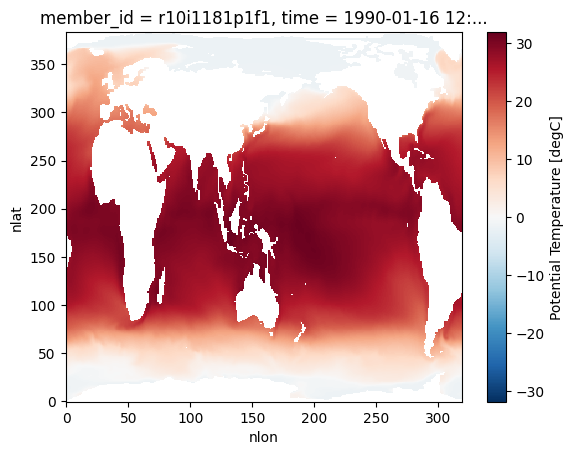

In [1]:
from grab_cesm import open_cesm2le

# Load CESM data
temp = open_cesm2le(
    "TEMP",
    component="ocn",
    scenario="historical",
    forcing="cmip6",
    time_slice=("1990-01", "1991-12"),
    members=0,
)

# Inspect data
print(temp)
print(temp.dims)
print(list(temp.coords))

# Extract surface
temp_surface = temp.isel(z_t=0)

# Plot first timestep
temp_surface.isel(time=0).load().plot()